In [1]:
# Import Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [2]:
df1=pd.read_csv(r"C:\Users\Lenovo\Downloads\E-commerce_Customer_Segmentation_2026.csv")

In [3]:
df1.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [4]:
df1.shape

(50000, 53)

In [5]:
core_cols=[
'customer_id','customer_segment','age','gender','country','income_bracket','tenure_months',
'total_purchases','avg_order_value_usd','total_spent_usd','purchase_frequency',
'days_since_last_purchase','preferred_category_1','shopping_channel','device_used',
'payment_method','return_count','complaint_count','satisfaction_score','loyalty_tier',
'email_open_rate','click_through_rate','conversion_rate','customer_lifetime_value_usd',
'customer_acquisition_cost_usd','customer_profitability_usd','rfm_score','churn_risk_score',
'customer_health_score'
]
df2=df1[core_cols].copy()

In [6]:
df2.shape

(50000, 29)

In [7]:
df2.head()

,customer_id,customer_segment,age,gender,country,income_bracket,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,...,loyalty_tier,email_open_rate,click_through_rate,conversion_rate,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,rfm_score,churn_risk_score,customer_health_score
0,CUST-000001,Consumer,70,Male,Canada,150K+,77,28,912.60,25552.80,...,Platinum,0.018,0.067,0.022,21281.07,96.74,21184.33,10,39,100
1,CUST-000002,Premium,53,Female,Germany,25K-50K,80,75,300.86,22564.50,...,Gold,0.084,0.085,0.293,28347.21,199.28,28147.93,8,42,100
2,CUST-000003,Consumer,82,Male,Mexico,75K-100K,86,163,663.91,108217.33,...,Diamond,0.279,0.428,0.222,103909.84,112.39,103797.45,13,0,100
3,CUST-000004,Enterprise,18,Male,Singapore,150K+,26,192,613.60,117811.20,...,Diamond,0.899,0.282,0.142,171318.41,140.71,171177.70,15,14,100
4,CUST-000005,Premium,64,Male,United Arab Emirates,150K+,90,31,651.65,20201.15,...,Gold,0.835,0.094,0.180,24465.47,52.82,24412.65,11,45,60


In [8]:
df2.columns.tolist()

['customer_id',
 'customer_segment',
 'age',
 'gender',
 'country',
 'income_bracket',
 'tenure_months',
 'total_purchases',
 'avg_order_value_usd',
 'total_spent_usd',
 'purchase_frequency',
 'days_since_last_purchase',
 'preferred_category_1',
 'shopping_channel',
 'device_used',
 'payment_method',
 'return_count',
 'complaint_count',
 'satisfaction_score',
 'loyalty_tier',
 'email_open_rate',
 'click_through_rate',
 'conversion_rate',
 'customer_lifetime_value_usd',
 'customer_acquisition_cost_usd',
 'customer_profitability_usd',
 'rfm_score',
 'churn_risk_score',
 'customer_health_score']

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   age                            50000 non-null  int64  
 3   gender                         50000 non-null  object 
 4   country                        50000 non-null  object 
 5   income_bracket                 50000 non-null  object 
 6   tenure_months                  50000 non-null  int64  
 7   total_purchases                50000 non-null  int64  
 8   avg_order_value_usd            50000 non-null  float64
 9   total_spent_usd                50000 non-null  float64
 10  purchase_frequency             50000 non-null  object 
 11  days_since_last_purchase       50000 non-null  int64  
 12  preferred_category_1           50000 non-null 

In [10]:
df2.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,rfm_score,churn_risk_score,customer_health_score
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,45.64802,59.748240,99.418460,505.366911,50266.546156,62.971240,9.511740,6.99380,3.007960,0.500319,0.250748,0.150368,57722.068910,102.453505,57619.615405,11.794460,26.84122,86.674100
std,18.36795,34.310128,57.780178,285.604037,44071.209164,93.281404,5.782592,4.32425,1.417976,0.289515,0.144259,0.086877,52437.283546,56.373987,52437.172654,2.680507,19.20729,16.107113
min,18.00000,1.000000,0.000000,10.050000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,5.010000,-199.870000,3.000000,0.00000,30.000000
25%,30.00000,30.000000,49.000000,259.067500,13893.577500,2.000000,4.000000,3.00000,2.000000,0.251000,0.127000,0.075000,15488.650000,53.820000,15372.800000,10.000000,10.00000,75.000000
50%,45.00000,60.000000,99.000000,504.790000,37541.625000,19.000000,10.000000,7.00000,3.000000,0.500000,0.251000,0.150000,42236.310000,102.320000,42129.690000,12.000000,25.00000,95.000000
75%,60.00000,90.000000,150.000000,752.702500,76811.242500,77.000000,15.000000,11.00000,4.000000,0.752000,0.375250,0.226000,86714.875000,151.260000,86608.330000,14.000000,40.00000,100.000000
max,84.00000,119.000000,199.000000,999.990000,198574.140000,365.000000,19.000000,14.00000,5.000000,1.000000,0.500000,0.300000,294634.150000,200.000000,294479.720000,15.000000,100.00000,100.000000


In [11]:
df2.duplicated().sum()

np.int64(0)

In [12]:
df2.isnull().sum()

customer_id                         0
customer_segment                    0
age                                 0
gender                              0
country                             0
income_bracket                      0
tenure_months                       0
total_purchases                     0
avg_order_value_usd                 0
total_spent_usd                     0
purchase_frequency                  0
days_since_last_purchase            0
preferred_category_1                0
shopping_channel                    0
device_used                         0
payment_method                      0
return_count                        0
complaint_count                     0
satisfaction_score                  0
loyalty_tier                     1272
email_open_rate                     0
click_through_rate                  0
conversion_rate                     0
customer_lifetime_value_usd         0
customer_acquisition_cost_usd       0
customer_profitability_usd          0
rfm_score   

In [13]:
df2["loyalty_tier"]=df2["loyalty_tier"].fillna(df2["loyalty_tier"].mode()[0])

In [14]:
df2.isnull().sum()

customer_id                      0
customer_segment                 0
age                              0
gender                           0
country                          0
income_bracket                   0
tenure_months                    0
total_purchases                  0
avg_order_value_usd              0
total_spent_usd                  0
purchase_frequency               0
days_since_last_purchase         0
preferred_category_1             0
shopping_channel                 0
device_used                      0
payment_method                   0
return_count                     0
complaint_count                  0
satisfaction_score               0
loyalty_tier                     0
email_open_rate                  0
click_through_rate               0
conversion_rate                  0
customer_lifetime_value_usd      0
customer_acquisition_cost_usd    0
customer_profitability_usd       0
rfm_score                        0
churn_risk_score                 0
customer_health_scor

In [15]:
segment_count=df2["customer_segment"].value_counts()
print(segment_count)

customer_segment
Consumer          22507
Premium           12423
Small Business     9979
Enterprise         5091
Name: count, dtype: int64


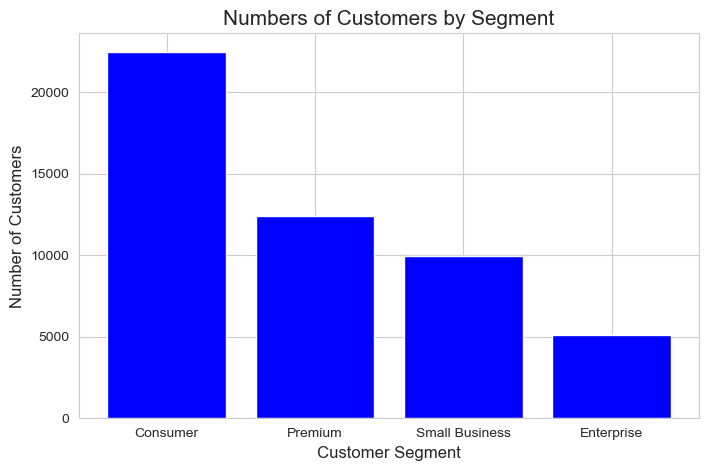

In [16]:
plt.figure(figsize=(8,5))
plt.bar(segment_count.index,segment_count.values,color="b")
plt.title("Numbers of Customers by Segment",fontsize=15)
plt.xlabel("Customer Segment",fontsize=12)
plt.ylabel("Number of Customers",fontsize=12)
plt.show()

In [17]:
avg_revenue_by_segment=df2.groupby("customer_segment")["total_spent_usd"].mean()
print(avg_revenue_by_segment)

customer_segment
Consumer          50451.873792
Enterprise        49120.288271
Premium           50461.559411
Small Business    50190.564607
Name: total_spent_usd, dtype: float64


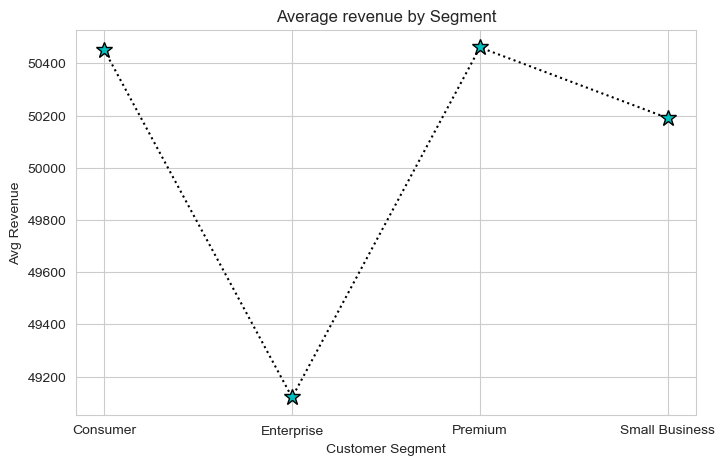

In [28]:
plt.figure(figsize=(8,5))
plt.plot(avg_revenue_by_segment.index,avg_revenue_by_segment.values,ls=":",color="k",marker="*",mfc="c",ms=12)
plt.title("Average revenue by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Avg Revenue")
plt.show()

In [26]:
shopping_by_channels=df2.groupby("shopping_channel")["total_spent_usd"].sum().sort_values(ascending=False)
print(shopping_by_channels)

shopping_channel
Mobile App     6.331953e+08
Online         6.330627e+08
In-Store       6.285937e+08
Marketplace    6.184757e+08
Name: total_spent_usd, dtype: float64


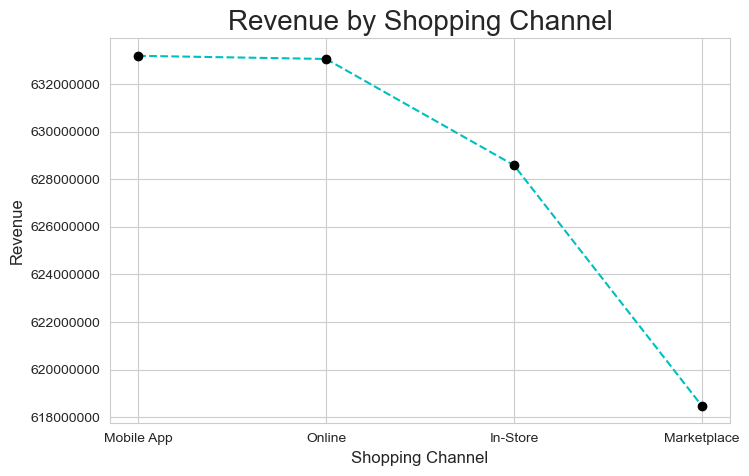

In [38]:
plt.figure(figsize=(8,5))
plt.plot(shopping_by_channels.index,shopping_by_channels.values,ls="--",color="c",marker=".",ms=12,mfc="k",mec="k")
plt.title("Revenue by Shopping Channel",fontsize=20)
plt.xlabel("Shopping Channel",fontsize=12)
plt.ylabel("Revenue",fontsize=12)
plt.ticklabel_format(style="plain",axis="y")
plt.show()